In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  MntFishProducts  \
0            0  04-09-2012      

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing 


## 1. Handle missing values - income 
fill it with median of all 


In [9]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering 
create new feature and delete some existing feature 
## Clustering algo can't interpreted date data properly 
Need to convert data into numerical format.

Year_Birth  ->  customer age  ->  add Age 

Dt_Customer  ->  joing data  ->  cutomer tenure days (how many days its been for customer, joing the platform)

eg (joing date)    (max days)    (tenure days)

   1 jan 2010 ->              -> 0
   
   5 jan 2010 ->              -> 2
   
   7 jan 2010 ->      max     -> 6

   max date => refernce date ( calculate how much time user have been on the platform)
   
   subtract all other date from  reference date 

In [12]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

## 1. Age

In [14]:
# new feature 1. -> Age
df["Age"] = 2026-df["Year_Birth"]

In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


## 2. Customer Tenure Days

In [17]:
# Converting date data into numeric data

# customer joining date 
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)

reference_date = df["Dt_Customer"].max()

#new feature -> 2. customer tenure days  ( calculate how much time user have been on the platform)
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [18]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


## 3. Total spending 

In [20]:
#new feature -> 3. total spending 
df["Total_Spending"] = df["MntWines"]+ df["MntFruits"]+df["MntMeatProducts"]+ df["MntFishProducts"]+ df["MntSweetProducts"]

In [21]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1529
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,21
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,734
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,48
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,407


## 4. Children

In [23]:
# new feature -> 4. children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [24]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1529,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,21,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,734,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,48,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,407,1


## 5. Education 

In [26]:
# new feature -> 5. Education 
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [27]:
# Education -> ( UG,G,PG)
df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate", "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master": "Postgraduate", "PhD":"Postgraduate"
})

In [28]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

## 6. Marital Status

In [30]:
# new feature -> 6. martial status

df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [31]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})

In [32]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop unnecessary columns 

In [34]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1529,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,21,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,734,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,48,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,407,1,Partner


In [35]:
cols = ["ID","Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [36]:
df_cleaned.shape

(2240, 15)

In [37]:
df.shape

(2240, 27)

In [38]:
df_cleaned.head()


,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,Partner


# Detecting Outliers

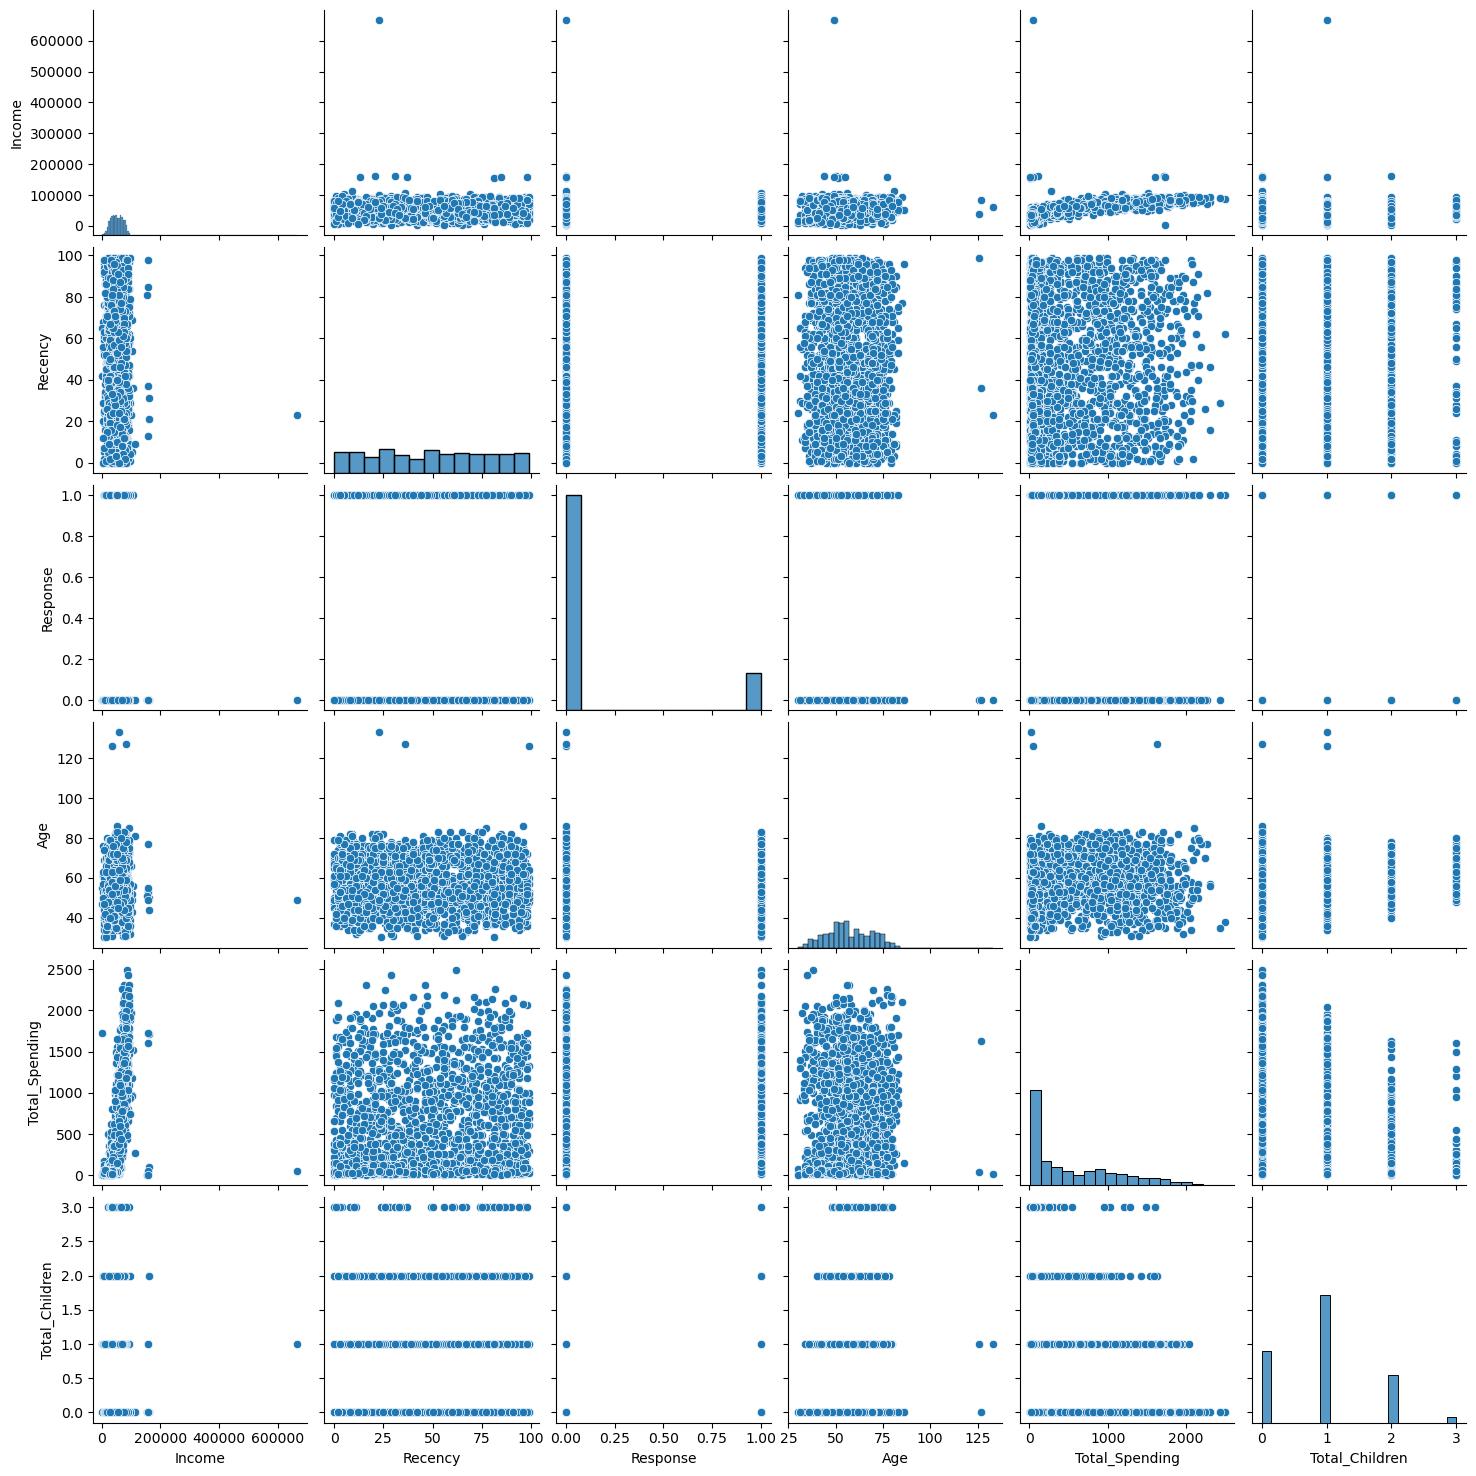

In [40]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

# Relative plots of some features -> PairPLot
sns.pairplot(df_cleaned[cols])

In [41]:
# Remove outliers 

print("data size with outliers: ", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[ (df_cleaned["Income"]<600_000)]

print("data size without outliers: ", len(df_cleaned))

data size with outliers:  2240
data size without outliers:  2236


# Heatmap

In [43]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

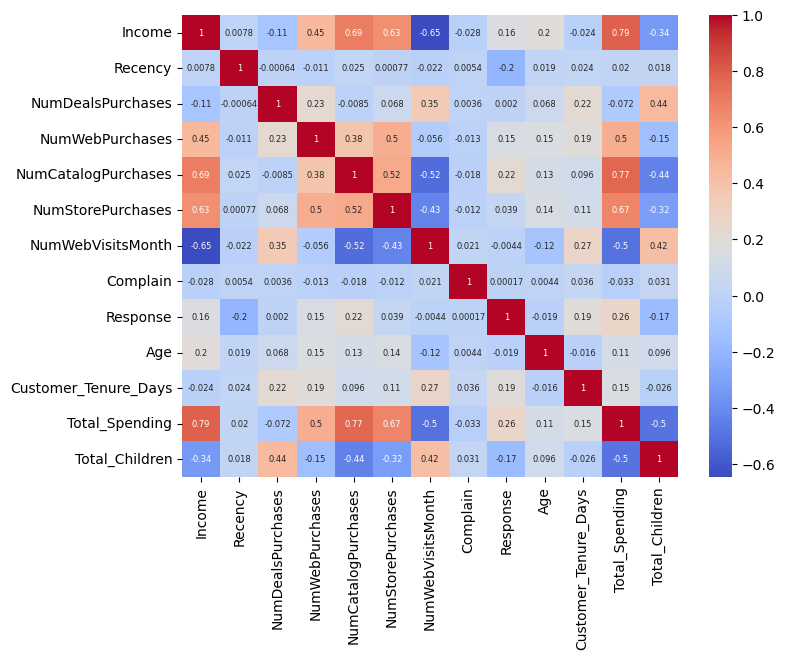

In [44]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws = {"size":6},
    cmap = "coolwarm"
)

In [45]:
df_cleaned.shape

(2236, 15)

In [46]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,Partner


# EnCoding 

In [48]:
from sklearn.preprocessing import OneHotEncoder

In [49]:
ohe = OneHotEncoder()

cat_cols =["Education","Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [50]:
enc_df = pd.DataFrame(enc_cols.toarray(), 
                      columns=ohe.get_feature_names_out(cat_cols),
                      index=df_cleaned.index)


In [51]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [52]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols),enc_df], axis=1)

In [53]:
df_encoded.shape

(2236, 18)

In [54]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,0.0,1.0,0.0,0.0,1.0


# Scaling 
Standardizing the data

In [56]:
from sklearn.preprocessing import StandardScaler

In [57]:
X = df_encoded

In [58]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize

In [60]:
X_scaled.shape

(2236, 18)

In [61]:
# 2D 
from sklearn.decomposition import PCA

In [62]:
pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)

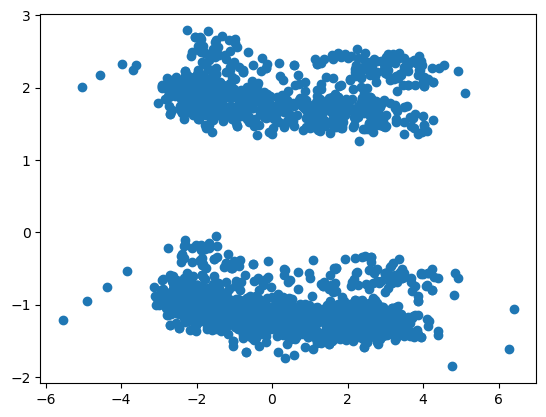

In [63]:
# plot 

plt.scatter(X_pca[:,0], X_pca[:,1])

In [64]:
# Variance 
pca.explained_variance_ratio_

array([0.23125129, 0.11385768])

variance = 23+11 = 34 variance captures

100-34 = lost (majority info)

increase n_component value 

Text(0.5, 0.92, '3d projected')

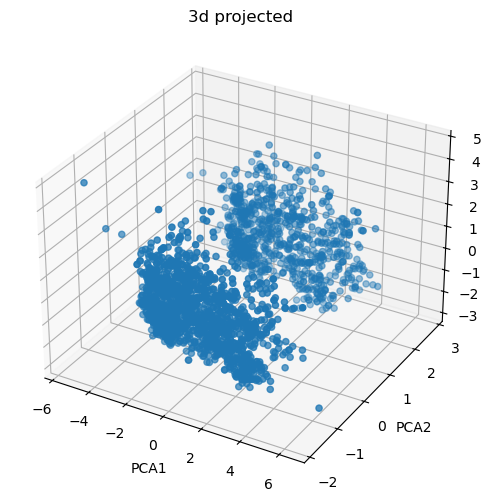

In [66]:
# plot n_component inc -> 3D 
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_xlabel("PCA3")
ax.set_xlabel("PCA1")
ax.set_title("3d projected")

# Analyze K value 
## 1. Elbow Method

In [69]:
! pip install kneed

  Using cached kneed-0.8.6-py3-none-any.whl.metadata (6.4 kB)
Using cached kneed-0.8.6-py3-none-any.whl (10 kB)


In [73]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [75]:
knee = KneeLocator(range(1,11), wcss, curve = "convex", direction = "decreasing")
optimal_k = knee.elbow

In [77]:
print("Best K = ", optimal_k)

Best K =  4


Text(0, 0.5, 'wcss')

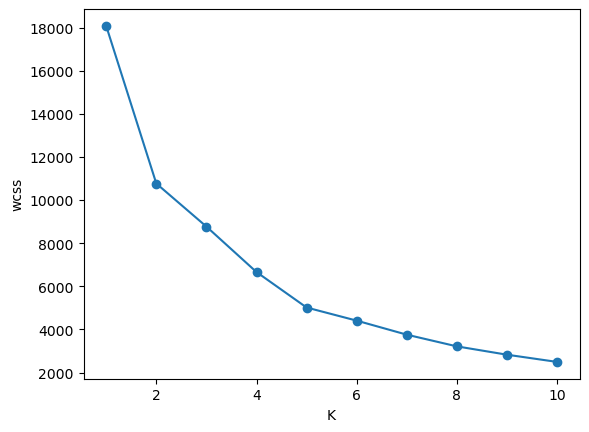

In [81]:
# plot

plt.plot(range(1,11),wcss,marker = 'o')
plt.xlabel("K")
plt.ylabel("wcss")

## 2.Silhouette Score

Text(0, 0.5, 'Silhouette score')

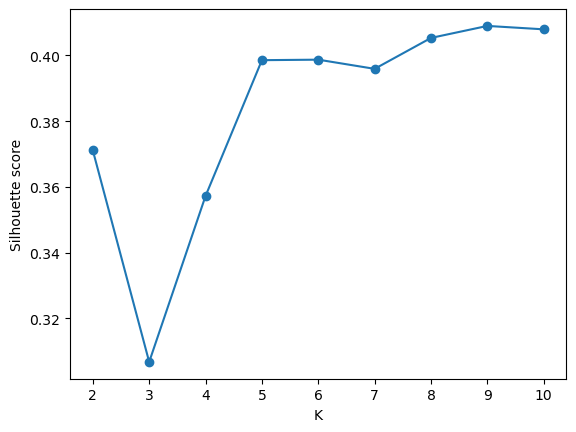

In [86]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

#plot 
plt.plot(range(2,11),scores,marker = 'o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'Silhouette Score')

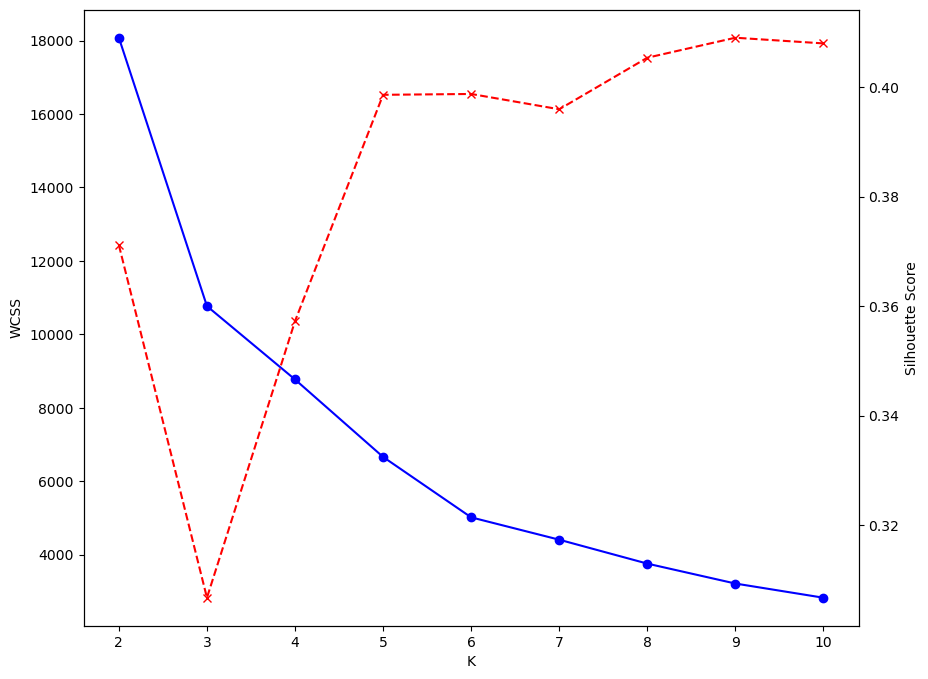

In [104]:
# combine plot 

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(10,8))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker = "x", color = "red", linestyle = "--")
ax2.set_ylabel("Silhouette Score")

# Clustering 

In [107]:
# K_means

kmeans = KMeans(n_clusters = 4, random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)

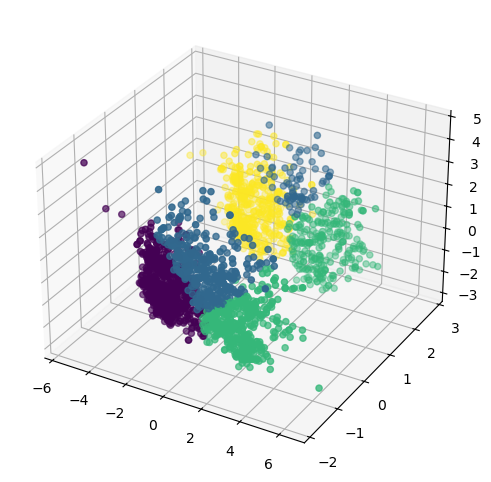

In [113]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111, projection ="3d")

ax.scatter(X_pca[:,0], X_pca[:, 1], X_pca[:,2], c = labels_kmeans) 

In [117]:
# Agglomearative Clustering 
from sklearn.cluster import AgglomerativeClustering 

In [123]:
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage ="ward")
labels_agg =agg_clf.fit_predict(X_pca)

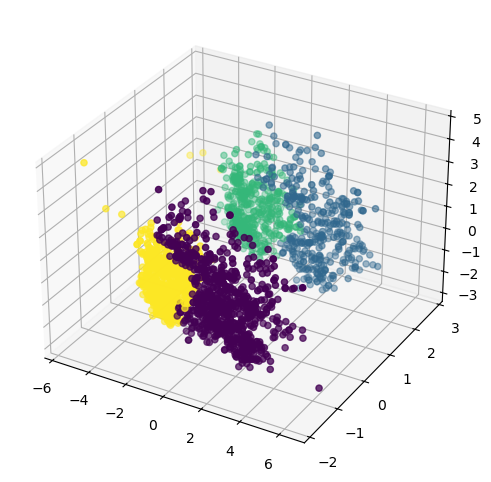

In [129]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111, projection ="3d")

ax.scatter(X_pca[:,0], X_pca[:, 1], X_pca[:,2], c = labels_agg)


# Characterization of Clusters 

In [203]:
# adding agglomerative labels in the original(cleaned, encoded) dataset

X["cluster"] =  labels_agg

In [205]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,1.0,0.0,1
1,46344.0,38,2,1,1,2,5,0,0,72,113,21,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,734,0,1.0,0.0,0.0,0.0,1.0,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,48,1,1.0,0.0,0.0,0.0,1.0,3
4,58293.0,94,5,5,3,6,5,0,0,45,161,407,1,0.0,1.0,0.0,0.0,1.0,3


<Axes: xlabel='cluster', ylabel='count'>

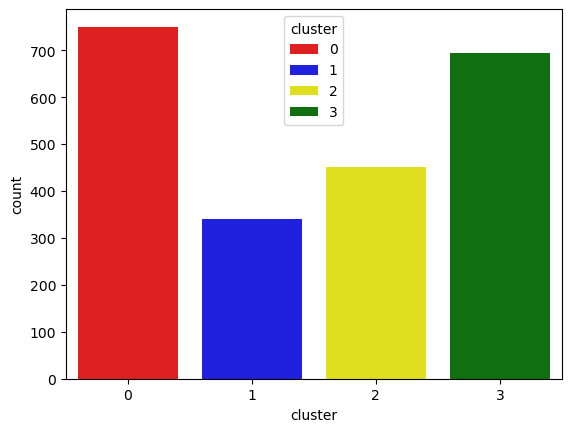

In [207]:
# identify plot in whichtype of cluster, whichtype of info is present

# no of customer in each cluster 
pal = ["red","blue","yellow","green"]

sns.countplot(x = X["cluster"], palette = pal, hue = X["cluster"])


<Axes: xlabel='Total_Spending', ylabel='Income'>

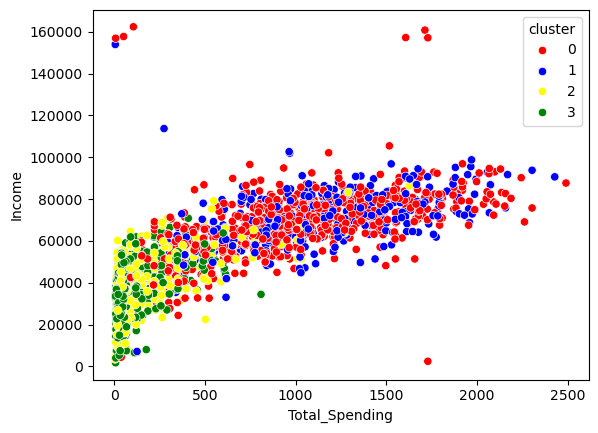

In [209]:
# Income & Spending pattern

sns.scatterplot(x = X["Total_Spending"], y = X["Income"], hue = X["cluster"], palette = pal )

In [213]:
# Cluster summry 

cluster_summary  = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        67291.757333  49.062667           2.460000         5.625333   
1        70458.914706  50.088235           1.908824         5.761765   
2        38551.119734  48.669623           2.465632         2.855876   
3        35042.648921  48.988489           2.294964         2.408633   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   4.532000           8.021333           4.153333  0.006667   
1                   5.055882           8.314706           3.682353  0.005882   
2                   0.935698           3.893570           6.443459  0.011086   
3                   0.597122           3.395683           6.647482  0.011511   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         